In [1]:
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from magE.constutils import *
from magE.plotutils import *
from magE.functions import gaussian
import uncertainties.umath as uum
from uncertainties import ufloat
import uncertainties.unumpy as upy
import os
os.getcwd()

'/home/benjamin/Documents/analogs'

In [2]:
# Equivalent width dictionaries
balmer_abs = pd.read_csv('./results/balmer_absorption/balmer_abs_oplb_we.csv')
balmer_em = pd.read_csv('./results/ew_lines_final.csv')

# Catalog of line fluxes
line_fluxes = pd.read_csv('./results/em_lines_final.csv')

# Correcting values

In [3]:
# Masks to order the data by RA
mask_abs = np.argsort(balmer_abs['Galaxy'])
mask_em = np.argsort(balmer_em['galname'])
mask_lines = np.argsort(line_fluxes['galname'])

In [5]:
# EWs of absorption lines
EW_Ha_abs = balmer_abs['EW_Ha'][mask_abs].drop(0)
#EW_Ha_abs_err = balmer_abs['EW_Ha_err'][mask_abs].drop(0)
EW_Hb_abs = balmer_abs['EW_Hb'][mask_abs].drop(0)
#EW_Hb_abs_err = balmer_abs['EW_Hb_err'][mask_abs].drop(0)

# Stellar continuum level of emission lines
bkg_Ha_em = line_fluxes['Ha'][mask_lines] / balmer_em['Ha'][mask_em]
bkg_Hb_em = line_fluxes['Hb'][mask_lines] / balmer_em['Hb'][mask_em]

In [6]:
# Measured absorption line fluxes in units of emission line fluxes

# EW_abs * bkg_em = F_abs (to compare with F_em)
F_Ha_abs = EW_Ha_abs.to_numpy() * bkg_Ha_em.to_numpy()
F_Hb_abs = EW_Hb_abs.to_numpy() * bkg_Hb_em.to_numpy()

In [7]:
# Correction percentage
pCorr_Ha = 100 * ((line_fluxes['Ha'][mask_lines] + F_Ha_abs) - line_fluxes['Ha'][mask_lines]) / line_fluxes['Ha'][mask_lines]
pCorr_Hb = 100 * ((line_fluxes['Hb'][mask_lines] + F_Hb_abs) - line_fluxes['Hb'][mask_lines]) / line_fluxes['Hb'][mask_lines]

In [8]:
print('Maximum Ha correction (%)')
print(np.max(100 * ((line_fluxes['Ha'][mask_lines] + F_Ha_abs) - line_fluxes['Ha'][mask_lines]) / line_fluxes['Ha'][mask_lines]))
print('Mean Ha correction (%)')
print(np.mean(100 * ((line_fluxes['Ha'][mask_lines] + F_Ha_abs) - line_fluxes['Ha'][mask_lines]) / line_fluxes['Ha'][mask_lines]))

Maximum Ha correction (%)
1.7000663029189165
Mean Ha correction (%)
0.8593285649182509


In [9]:
print('Maximum Hb correction (%)')
print(np.max(100 * ((line_fluxes['Hb'][mask_lines] + F_Hb_abs) - line_fluxes['Hb'][mask_lines]) / line_fluxes['Hb'][mask_lines]))
print('Mean Hb correction (%)')
print(np.mean(100 * ((line_fluxes['Hb'][mask_lines] + F_Hb_abs) - line_fluxes['Hb'][mask_lines]) / line_fluxes['Hb'][mask_lines]))

Maximum Hb correction (%)
11.305646617096537
Mean Hb correction (%)
5.275025516438711


# Table for latex

In [9]:
galnames_ext.remove('J2212+0006_comp')

In [10]:
dict_ew = {'ID': np.sort(np.array(galnames_ext)),
           'EW_Ha_em': upy.uarray(balmer_em['Ha'][mask_em], balmer_em['Ha_err'][mask_em]),
           'EW_Hb_em': upy.uarray(balmer_em['Hb'][mask_em], balmer_em['Hb_err'][mask_em]),
           'EW_Ha_abs': upy.uarray(EW_Ha_abs, EW_Ha_abs_err),
           'EW_Hb_abs': upy.uarray(EW_Hb_abs, EW_Hb_abs_err),
           'pCorr_Ha': pCorr_Ha,
           'pCorr_hb': pCorr_Hb
          }

dict_ew_pd = pd.DataFrame(data=dict_ew, index=None)

In [16]:
np.mean(line_fluxes['Ha_err'] / line_fluxes['Ha']) * 100

0.190123589061802

In [17]:
np.mean(line_fluxes['Hb_err'] / line_fluxes['Hb']) * 100

0.32559756011451796

In [12]:
dict_ew_pd.to_latex(index=False, float_format='%.3f')

'\\begin{tabular}{lllllrr}\n\\toprule\nID & EW_Ha_em & EW_Hb_em & EW_Ha_abs & EW_Hb_abs & pCorr_Ha & pCorr_hb \\\\\n\\midrule\nJ0021+0052 & 500.1+/-1.5 & 98.6+/-0.4 & 3.21+/-0.20 & 5.1+/-0.9 & 0.641 & 5.203 \\\\\nJ0023-0948 & 684+/-4 & 179.4+/-1.9 & 4.59+/-0.19 & 5.4+/-1.0 & 0.672 & 2.982 \\\\\nJ0136-0037 & 487+/-6 & 120.2+/-2.0 & 4.97+/-0.23 & 6.8+/-1.0 & 1.021 & 5.652 \\\\\nJ0240-0828 & 1046+/-10 & 329+/-5 & 3.75+/-0.20 & 4.1+/-0.9 & 0.358 & 1.236 \\\\\nJ0252+0114 & 384+/-4 & 100.2+/-1.7 & 4.84+/-0.23 & 6.6+/-1.0 & 1.261 & 6.572 \\\\\nJ0305+0040 & 336+/-4 & 85.1+/-1.5 & 5.08+/-0.23 & 6.9+/-1.0 & 1.515 & 8.106 \\\\\nJ0950+0042 & 340.2+/-1.2 & 106.6+/-0.5 & 3.06+/-0.17 & 4.0+/-0.9 & 0.900 & 3.710 \\\\\nJ1146+0053 & 584+/-8 & 148.3+/-2.0 & 4.61+/-0.19 & 5.4+/-1.0 & 0.790 & 3.620 \\\\\nJ1226+0415 & 1039+/-6 & 216.3+/-1.5 & 4.67+/-0.24 & 6.2+/-1.1 & 0.449 & 2.870 \\\\\nJ1444+0409 & 926+/-12 & 227+/-5 & 4.57+/-0.22 & 5.2+/-0.9 & 0.494 & 2.290 \\\\\nJ1448-0110 & 706.1+/-1.9 & 151.4+/-0.6 & 

---

In [3]:
ratio_ha = []
ratio_hb = []

ha_ew_em = []
ha_ew_abs = []
hb_ew_em = []
hb_ew_abs = []

for i in range(len(balmer_em['galname'])):
    
    mask = (balmer_abs['Galaxy'] == balmer_em['galname'][i]).to_numpy()

    
    ha_em_ew = float(balmer_em['Ha'][i])
    ha_abs_ew = float(balmer_abs['EW_Ha'][mask].iloc[0])
    
    hb_em_ew = float(balmer_em['Hb'][i])
    hb_abs_ew = float(balmer_abs['EW_Hb'][mask].iloc[0])
    
    ha_ew_em.append(ha_em_ew)
    ha_ew_abs.append(ha_abs_ew)
    hb_ew_em.append(hb_em_ew)
    hb_ew_abs.append(hb_abs_ew)
    
    ratio_ha.append(ha_abs_ew / ha_em_ew)
    ratio_hb.append(hb_abs_ew / hb_em_ew)
    
    
    
    print('=======================================')
    print(balmer_em['galname'][i])
    print('Ha EW percentage (abs/em): ', round(ha_abs_ew / ha_em_ew, 3))
    print('Hb EW percentage (abs/em): ', round(hb_abs_ew / hb_em_ew, 3))
    
ha_ew_em = np.array(ha_ew_em)
ha_ew_abs = np.array(ha_ew_abs)
hb_ew_em = np.array(hb_ew_em)
hb_ew_abs = np.array(hb_ew_abs)

J0021
Ha EW percentage (abs/em):  0.006
Hb EW percentage (abs/em):  0.058
J0023
Ha EW percentage (abs/em):  0.006
Hb EW percentage (abs/em):  0.039
J0136
Ha EW percentage (abs/em):  0.008
Hb EW percentage (abs/em):  0.051
J0240
Ha EW percentage (abs/em):  0.004
Hb EW percentage (abs/em):  0.019
J0252
Ha EW percentage (abs/em):  0.012
Hb EW percentage (abs/em):  0.066
J0305
Ha EW percentage (abs/em):  0.017
Hb EW percentage (abs/em):  0.106
J0950
Ha EW percentage (abs/em):  0.014
Hb EW percentage (abs/em):  0.057
J1146
Ha EW percentage (abs/em):  0.007
Hb EW percentage (abs/em):  0.041
J1226
Ha EW percentage (abs/em):  0.004
Hb EW percentage (abs/em):  0.03
J1444
Ha EW percentage (abs/em):  0.004
Hb EW percentage (abs/em):  0.019
J1448
Ha EW percentage (abs/em):  0.008
Hb EW percentage (abs/em):  0.047
J1624
Ha EW percentage (abs/em):  0.007
Hb EW percentage (abs/em):  0.05
J2101
Ha EW percentage (abs/em):  0.015
Hb EW percentage (abs/em):  0.084
J2119
Ha EW percentage (abs/em):  0.015


In [4]:
cont_ha = line_fluxes['Ha'] / ha_ew_em

corr_fl_ha = (ha_ew_em - ha_ew_abs) * cont_ha

percent_change_ha = (line_fluxes['Ha'] - corr_fl_ha) / line_fluxes['Ha']
percent_err_ha = line_fluxes['Ha_err'] / line_fluxes['Ha']

In [5]:
cont_hb = line_fluxes['Hb'] / hb_ew_em

corr_fl_hb = (hb_ew_em - hb_ew_abs) * cont_hb

percent_change_hb = (line_fluxes['Hb'] - corr_fl_hb) / line_fluxes['Hb']
percent_err_hb = line_fluxes['Hb_err'] / line_fluxes['Hb']

In [6]:
np.mean(percent_change_ha) * 100

0.8633026069747123

In [7]:
np.mean(percent_change_hb) * 100

5.2241859254694365

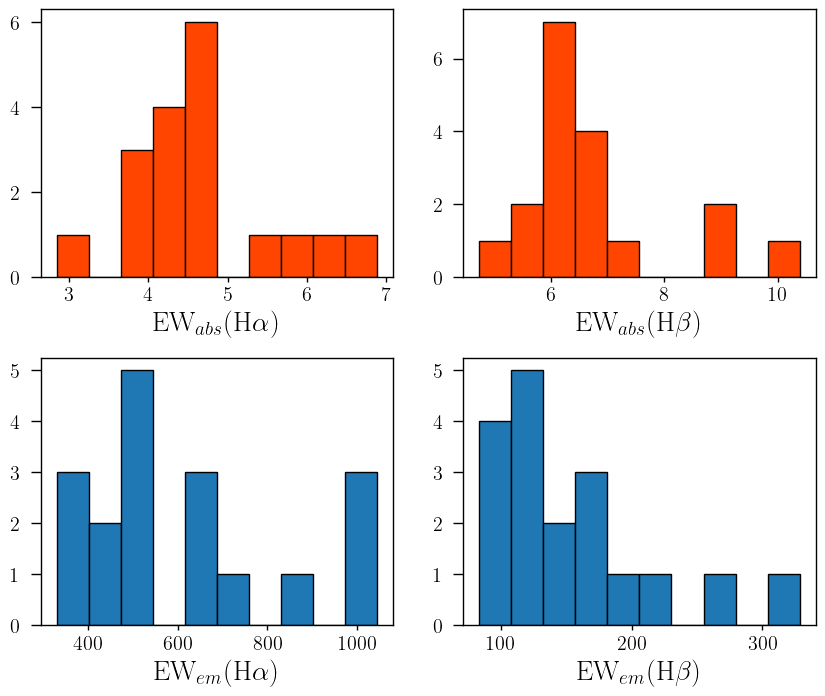

In [8]:
texPlot('on')
fig, axs = plt.subplots(2, 2)
fig.set_size_inches((10, 8))
fig.subplots_adjust(hspace=0.3)

axs[0, 0].hist(ha_ew_abs, facecolor='orangered', edgecolor='black')
axs[0, 0].set_xlabel(r'EW$_{abs}$(H$\alpha$)')

axs[0, 1].hist(hb_ew_abs, facecolor='orangered', edgecolor='black')
axs[0, 1].set_xlabel(r'EW$_{abs}$(H$\beta$)');

axs[1, 0].hist(ha_ew_em, edgecolor='black')
axs[1, 0].set_xlabel(r'EW$_{em}$(H$\alpha$)')

axs[1, 1].hist(hb_ew_em, edgecolor='black')
axs[1, 1].set_xlabel(r'EW$_{em}$(H$\beta$)');


In [13]:
100 * line_fluxes['Hb_err']/line_fluxes['Hb']

0     0.287271
1     0.357068
2     0.769671
3     0.429637
4     0.916752
5     1.074805
6     0.403815
7     0.751967
8     0.264274
9     0.593481
10    0.256982
11    1.050302
12    0.430861
13    0.632906
14    1.083899
15    0.344630
16    0.412069
17    0.444161
dtype: float64